# Mobile App Installer Retention Analysis

**Author:** Luis Cuevas  
**Tools:** Python 3.7.2 · pandas · scikit-learn · matplotlib · seaborn  
**Dataset:** 6,417 records across 9 monthly CSV files (April–December 2019)  
**Goal:** Understand and predict 30-day user retention for a mobile application using regression, classification trees, and ensemble methods.

---

## Project Overview

This notebook consolidates a full end-to-end analytics pipeline:

1. **Data Ingestion & Transformation** — Parse and standardize nine raw monthly CSV files with mixed encodings and date formats
2. **Data Curation** — Resolve data quality issues and merge into a single analysis-ready dataset
3. **Regression Modeling** — Linear and logistic regression to predict 30-day retention
4. **Classification Modeling** — Decision tree and random forest models with ROC AUC evaluation
5. **Visualization** — Bar charts, line charts, seaborn regression and pair plots, prediction scatter plots

---


## 1. Imports

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import sys

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")

pd.set_option('max_colwidth', 500)

## 2. Data Ingestion

Nine raw monthly CSV files (April–December 2019) are parsed from a single-column concatenated format into a structured 14-column DataFrame.  
Four files (Sep–Dec 2019) use UTF-16 Little Endian encoding; the remaining five use UTF-8.  
No cleaning is performed at this stage — raw ingestion is kept separate from curation (Wickham & Grolemund, 2017).

In [ ]:
files = [
    "retained_installers_com.foo.bar_201904_country.csv",
    "retained_installers_com.foo.bar_201905_country.csv",
    "retained_installers_com.foo.bar_201906_country.csv",
    "retained_installers_com.foo.bar_201907_country.csv",
    "retained_installers_com.foo.bar_201908_country.csv",
    "retained_installers_com.foo.bar_201909_country.csv",
    "retained_installers_com.foo.bar_201910_country.csv",
    "retained_installers_com.foo.bar_201911_country.csv",
    "retained_installers_com.foo.bar_201912_country.csv",
]

col_names = [
    "Date", "App", "Country", "Installers",
    "Retained_1d", "Retention_rate_1d",
    "Retained_7d", "Retention_rate_7d",
    "Retained_15d", "Retention_rate_15d",
    "Retained_30d", "Retention_rate_30d",
    "Retained_60d", "Retention_rate_60d"
]

dfs = []
for filename in files:
    try:
        raw = pd.read_csv(filename, header=None, names=["raw"], encoding="utf-8")
    except UnicodeDecodeError:
        raw = pd.read_csv(filename, header=None, names=["raw"], encoding="utf-16")
    df = raw["raw"].str.split(",", expand=True)
    df.columns = col_names
    dfs.append(df)
    print(f"{filename}: {df.shape}")

retained_installers_com.foo.bar_201904_country.csv: (889, 14)
retained_installers_com.foo.bar_201905_country.csv: (895, 14)
retained_installers_com.foo.bar_201906_country.csv: (790, 14)
retained_installers_com.foo.bar_201907_country.csv: (727, 14)
retained_installers_com.foo.bar_201908_country.csv: (778, 14)
retained_installers_com.foo.bar_201909_country.csv: (560, 14)
retained_installers_com.foo.bar_201910_country.csv: (582, 14)
retained_installers_com.foo.bar_201911_country.csv: (595, 14)
retained_installers_com.foo.bar_201912_country.csv: (601, 14)


## 3. Merge & Initial Exploration

All nine DataFrames are concatenated into a single dataset using `pd.concat()` with `ignore_index=True`.  
Expected shape: **6,417 rows × 14 columns**.

In [ ]:
data = pd.concat(dfs, ignore_index=True)
data.to_csv("app_retention_final.csv", index=False)

print("Shape:", data.shape)
print("\nFirst 10 rows:")
print(data.head(10).to_string())

print("\nDescription:")
print(data.describe())

print("\nCounts:")
print(data.count())

Shape: (6417, 14)

First 10 rows:
         Date          App Country Installers Retained_1d Retention_rate_1d Retained_7d Retention_rate_7d Retained_15d Retention_rate_15d Retained_30d Retention_rate_30d Retained_60d Retention_rate_60d
0  2019/04/01  com.foo.bar      AR          1           1             1.000           1             1.000            1              1.000            1              1.000            0              0.000
1  2019/04/01  com.foo.bar      AU          3           2             0.667           2             1.000            2              1.000            1              0.500            1              0.500
2  2019/04/01  com.foo.bar      AZ          1           0             0.000           0             0.000            0              0.000            0              0.000            0              0.000
3  2019/04/01  com.foo.bar      BR          1           0             0.000           0             0.000            0              0.000            0        

## 4. Data Curation & Cleaning

Three data quality issues are resolved:

- **Mixed date formats** — `YYYY/MM/DD` and `YYYY-MM-DD` standardized to `YYYY-MM-DD`
- **Blank country values** — one empty string in November 2019 replaced with `"Unknown"` to preserve numeric fields
- **Numeric type enforcement** — all retention columns cast via `pd.to_numeric(errors='coerce')`

Note: `pandas.count()` does not detect empty strings as missing values (McKinney, 2022), which is why the blank country required manual identification.

In [ ]:
# Standardize date format
data["Date"] = pd.to_datetime(data["Date"], format="mixed")
data["Date"] = data["Date"].dt.strftime("%Y-%m-%d")

# Replace blank country with Unknown
data["Country"] = data["Country"].replace("", "Unknown").fillna("Unknown")

# Enforce numeric types
numeric_cols = [
    "Installers", "Retained_1d", "Retained_7d",
    "Retained_15d", "Retained_30d", "Retained_60d"
]
data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors="coerce")

# Replace NaN in Retained_30d with 0
data["Retained_30d"] = data["Retained_30d"].fillna(0)

print("Missing values after curation:")
print(data.isnull().sum())

Missing values after curation:
Date                  14
App                    0
Country                0
Installers             0
Retained_1d            0
Retention_rate_1d      0
Retained_7d            0
Retention_rate_7d      0
Retained_15d           0
Retention_rate_15d     0
Retained_30d           0
Retention_rate_30d     0
Retained_60d           8
Retention_rate_60d     0
dtype: int64


## 5. Feature Engineering

A binary target column `Install_30` is created:  
- **1** if `Retained_30d > 0` (user was retained at 30 days)  
- **0** otherwise

This simplifies the prediction task from a 39-class problem to a clean binary classification.

In [ ]:
data["Install_30"] = (data["Retained_30d"] > 0).astype(int)

print("Install_30 distribution:")
print(data["Install_30"].value_counts())
print("\nTop 10 rows:")
print(data[["Installers", "Retained_30d", "Install_30"]].head(10))

Install_30 distribution:
Install_30
0    5162
1    1255
Name: count, dtype: int64

Top 10 rows:
   Installers  Retained_30d  Install_30
0           1             1           1
1           3             1           1
2           1             0           0
3           1             0           0
4           5             1           1
5           4             1           1
6           2             0           0
7           3             0           0
8           1             1           1
9           1             0           0


## 6. Visualization

### 6a. Installer Retention Bar Charts (1, 7, 15, 30 Days)

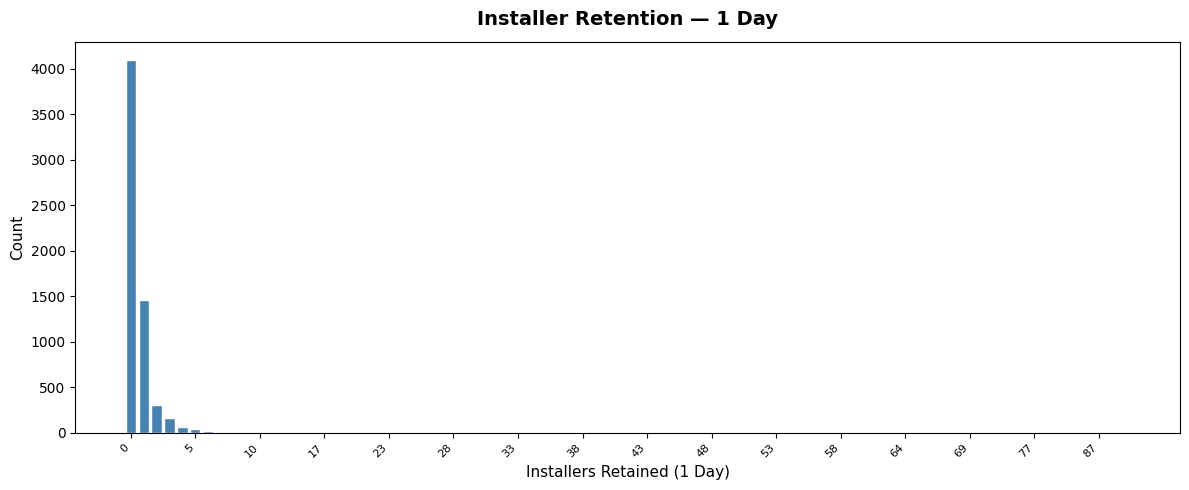

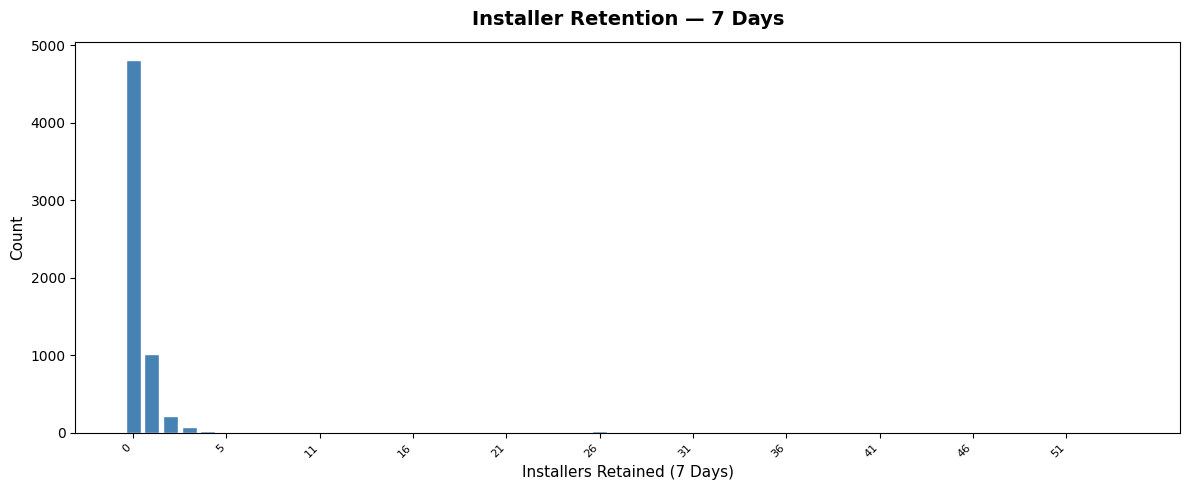

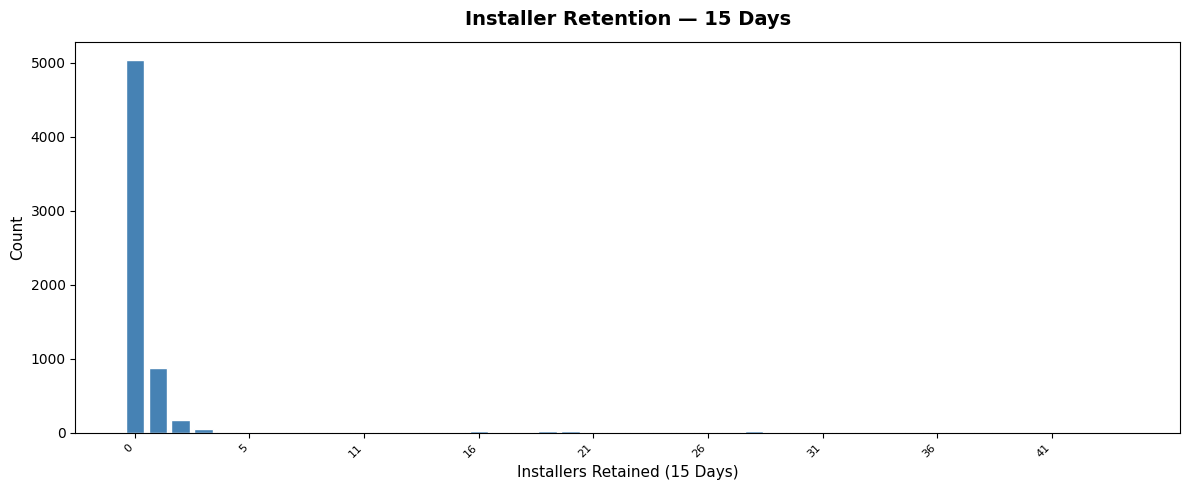

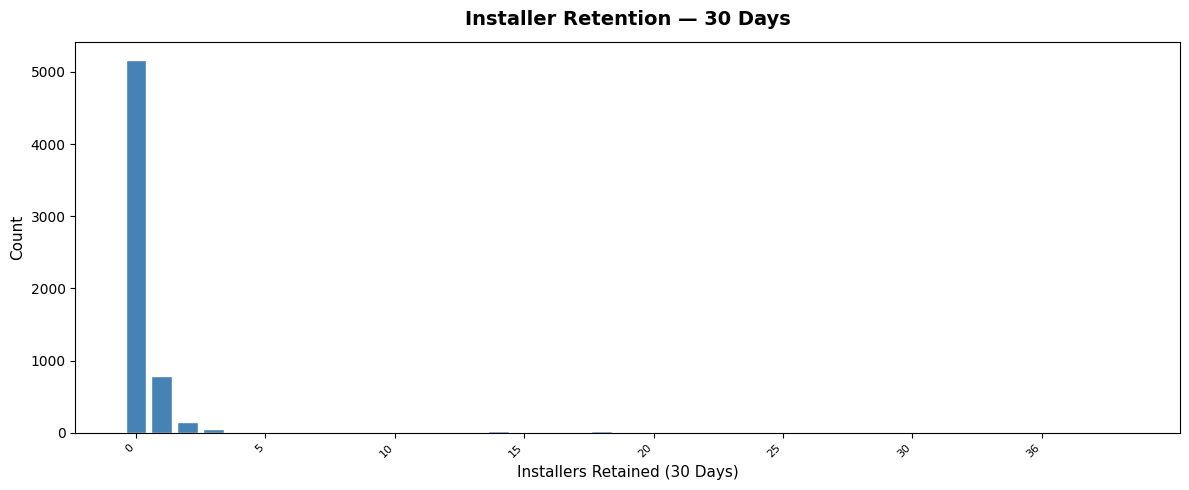

In [ ]:
retention_cols = [
    ("Retained_1d",  "Installer Retention — 1 Day",  "1 Day"),
    ("Retained_7d",  "Installer Retention — 7 Days", "7 Days"),
    ("Retained_15d", "Installer Retention — 15 Days","15 Days"),
    ("Retained_30d", "Installer Retention — 30 Days","30 Days"),
]

for col, title, xlabel in retention_cols:
    fig, ax = plt.subplots(figsize=(12, 5))
    counts = data[col].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(f"Installers Retained ({xlabel})", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_xticks(ax.get_xticks()[::5])
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()

### 6b. 30-Day Retention Over Time (Line Chart)

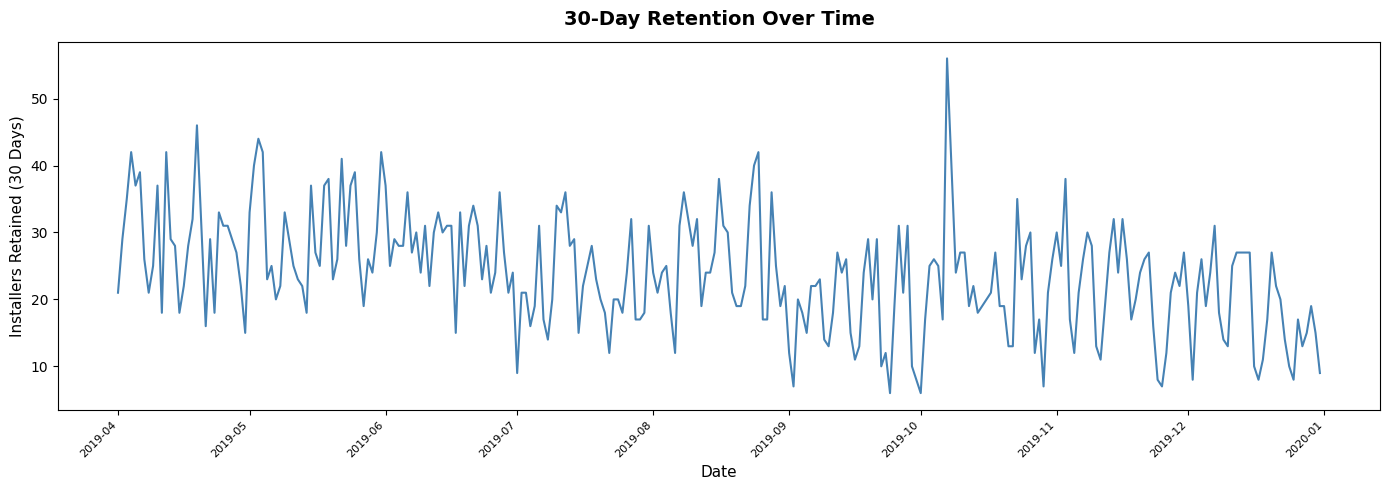

In [ ]:
data["Date"] = pd.to_datetime(data["Date"])
retention_by_date = data.groupby("Date")["Retained_30d"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(retention_by_date.index, retention_by_date.values, color="steelblue", linewidth=1.5)
ax.set_title("30-Day Retention Over Time", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Installers Retained (30 Days)", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

### 6c. Total Installs Per Month (Bar Chart)

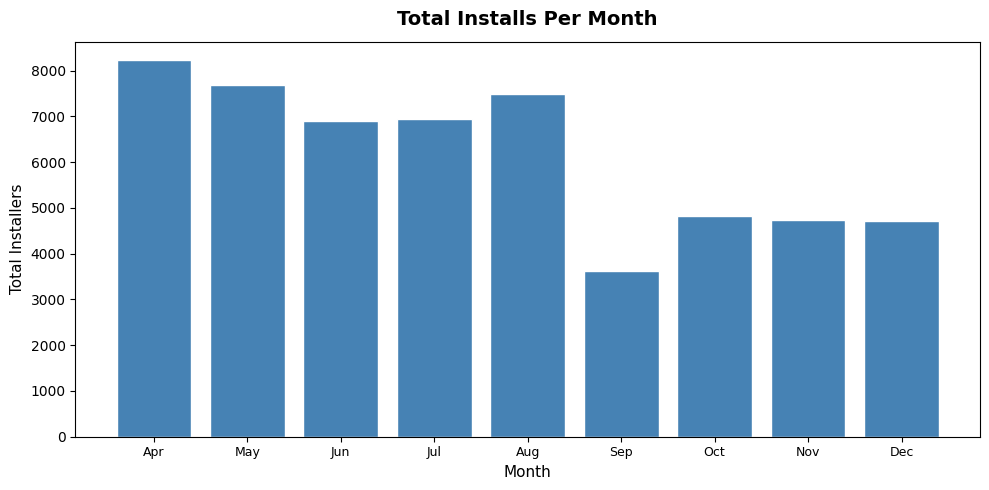

In [ ]:
data["Month"] = pd.DatetimeIndex(data["Date"]).month
installs_by_month = data.groupby("Month")["Installers"].sum()
month_names = {4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec",1:"Jan"}

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(installs_by_month.index, installs_by_month.values, color="steelblue", edgecolor="white")
ax.set_title("Total Installs Per Month", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Total Installers", fontsize=11)
ax.set_xticks(installs_by_month.index)
ax.set_xticklabels([month_names[m] for m in installs_by_month.index], fontsize=9)
plt.tight_layout()
plt.show()

### 6d. Seaborn Regression Plots (1, 7, 30 Days)

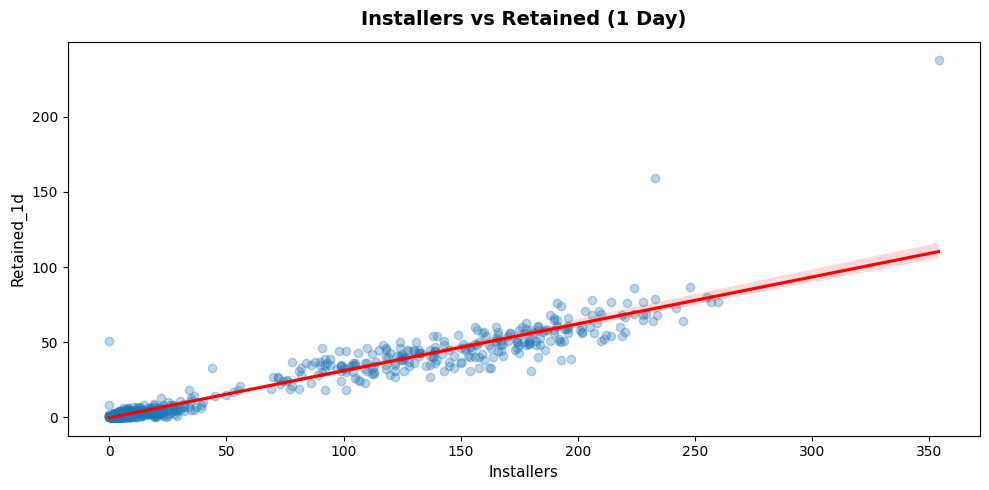

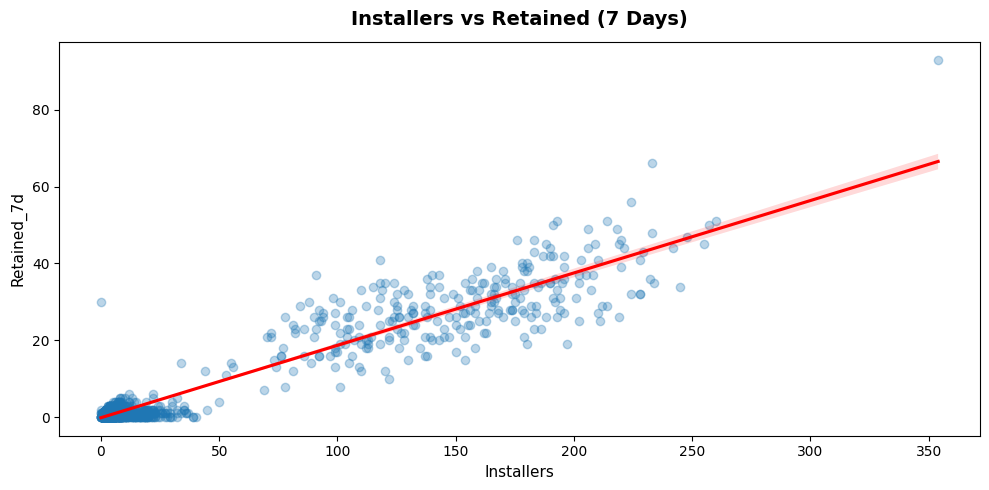

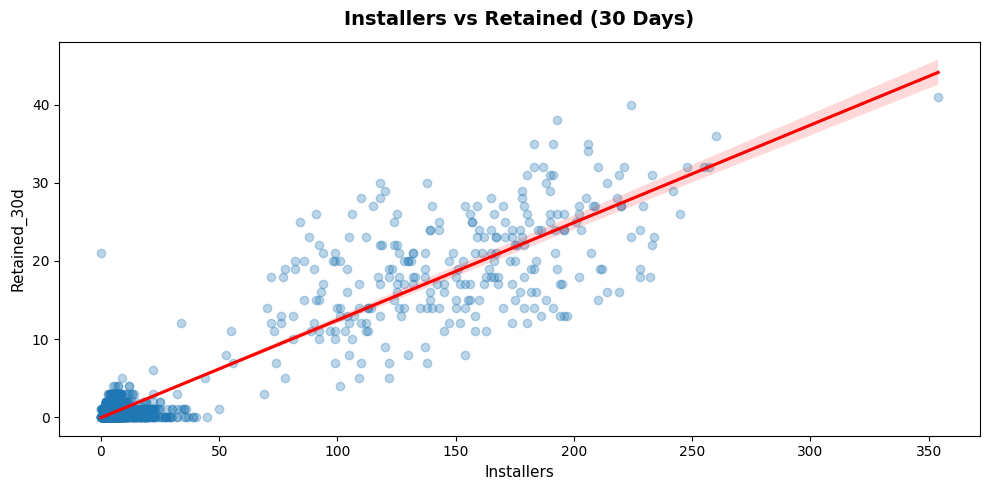

In [ ]:
reg_cols = [
    ("Retained_1d",  "Installers vs Retained (1 Day)"),
    ("Retained_7d",  "Installers vs Retained (7 Days)"),
    ("Retained_30d", "Installers vs Retained (30 Days)"),
]

for col, title in reg_cols:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.regplot(x="Installers", y=col, data=data, ax=ax,
                scatter_kws={"alpha": 0.3}, line_kws={"color": "red"})
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Installers", fontsize=11)
    ax.set_ylabel(col, fontsize=11)
    plt.tight_layout()
    plt.show()

### 6e. Seaborn Pairplot (1, 7, 15, 30-Day Retention)

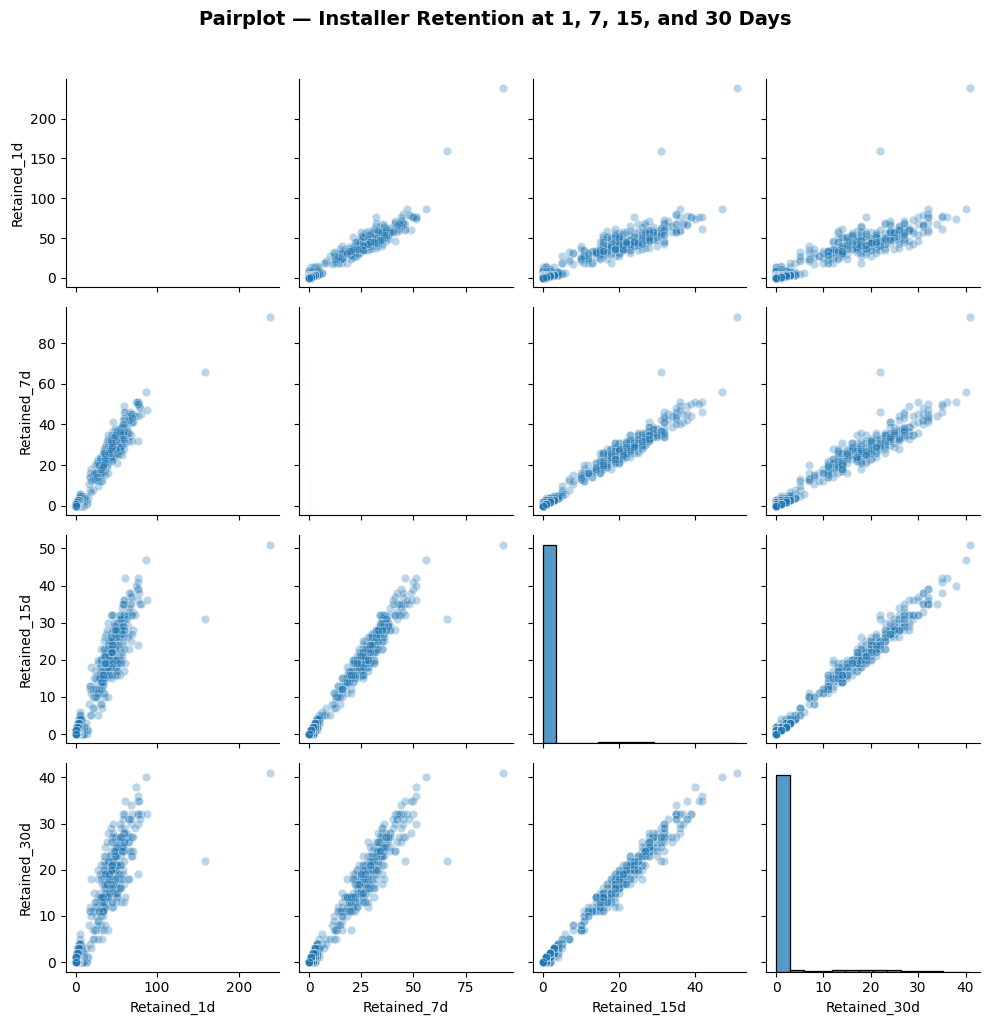

In [ ]:
pairplot_cols = ["Retained_1d", "Retained_7d", "Retained_15d", "Retained_30d"]
sns.pairplot(data[pairplot_cols], plot_kws={"alpha": 0.3})
plt.suptitle("Pairplot — Installer Retention at 1, 7, 15, and 30 Days",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Linear Regression

Predicts the expected number of users retained at 30 days based on installer count.

In [ ]:
X_lr = data[["Installers"]]
y_lr = data["Retained_30d"]

linear_model = LinearRegression()
linear_model.fit(X_lr, y_lr)

print("Intercept:", linear_model.intercept_)
print("Coefficient:", linear_model.coef_)
print("Prediction (1 install):", linear_model.predict([[1]]))
print("Prediction (2 installs):", linear_model.predict([[2]]))
print("Prediction (4 installs):", linear_model.predict([[4]]))

Intercept: -0.045030705782420855
Coefficient: [0.12474154]
Prediction (1 install): [0.07971084]
Prediction (2 installs): [0.20445238]
Prediction (4 installs): [0.45393547]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 8. Logistic Regression

### 8a. Multiclass Model (Raw Retained_30d as Target)

The raw `Retained_30d` column has 39 unique values, making this a multiclass problem.  
Included for comparison — the binary model in 8b is the preferred approach.

In [ ]:
X_log = data[["Installers"]]
y_log = data["Retained_30d"]

logistic_model = LogisticRegression(max_iter=5000)
logistic_model.fit(X_log, y_log)

print("Probability (1 install):", logistic_model.predict_proba([[1]]))
print("Probability (2 installs):", logistic_model.predict_proba([[2]]))
print("Probability (4 installs):", logistic_model.predict_proba([[4]]))

Probability (1 install): [[8.70490438e-01 1.07095311e-01 1.70079707e-02 4.74233606e-03
  4.42943942e-04 6.28827848e-05 7.59111015e-05 1.54969044e-05
  5.45008904e-06 8.40393042e-07 1.64695519e-05 1.89072851e-05
  1.08094142e-05 1.65538795e-06 3.22364990e-06 8.90800125e-07
  1.87325641e-07 8.98775816e-07 6.24619829e-07 5.77576361e-07
  3.26603710e-06 1.92291110e-06 4.25396793e-07 1.50220410e-07
  2.57533972e-08 2.04002847e-07 6.71764008e-08 8.69304601e-09
  5.14048217e-08 4.35263282e-09 4.83041226e-08 1.34853969e-10
  2.39811048e-12 1.31106116e-11 2.94359102e-10 8.25770992e-15
  7.98902951e-11 1.04219086e-12 4.68131664e-18]]
Probability (2 installs): [[8.53194466e-01 1.20380648e-01 1.99181803e-02 5.67603772e-03
  5.47888198e-04 8.08093949e-05 9.36673512e-05 2.02821640e-05
  7.17789609e-06 1.11829741e-06 2.14548542e-05 2.48674849e-05
  1.42774510e-05 2.22124288e-06 4.31892073e-06 1.20061330e-06
  2.54808367e-07 1.21369893e-06 8.45901921e-07 7.81949497e-07
  4.36758356e-06 2.58028723e-06 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### 8b. Binary Model (Install_30 as Target)

Using the engineered binary `Install_30` column produces a clean two-class output.  
This directly answers the business question: *will this user still be active at 30 days?*

In [ ]:
X_bin = data[["Installers"]]
y_bin = data["Install_30"]

logistic_model2 = LogisticRegression(max_iter=5000)
logistic_model2.fit(X_bin, y_bin)

print("Intercept:", logistic_model2.intercept_)
print("Coefficient:", logistic_model2.coef_)
print("\nProbability (1 install):", logistic_model2.predict_proba([[1]]))
print("Probability (2 installs):", logistic_model2.predict_proba([[2]]))
print("Probability (4 installs):", logistic_model2.predict_proba([[4]]))

Intercept: [-2.05816799]
Coefficient: [[0.14967982]]

Probability (1 install): [[0.87084921 0.12915079]]
Probability (2 installs): [[0.85306035 0.14693965]]
Probability (4 installs): [[0.81144834 0.18855166]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


### 8c. Predicted Class and Probability Scatter Plots

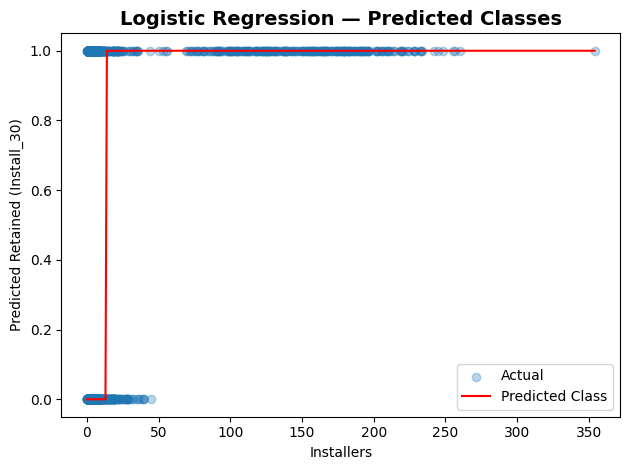

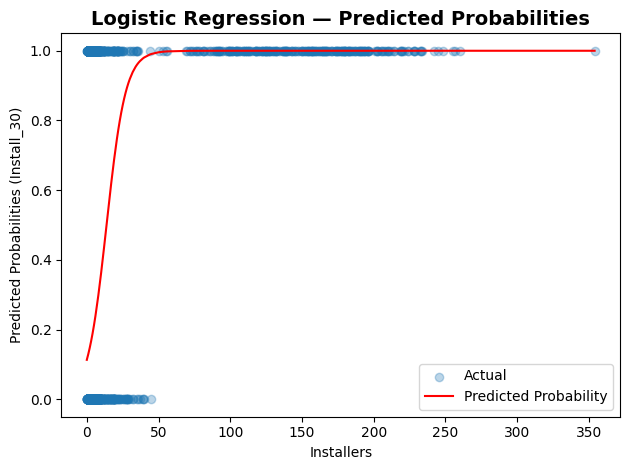

In [ ]:
# Predicted classes
assorted_pred_class = logistic_model2.predict(X_bin)
sorted_idx = data.Installers.argsort()

plt.scatter(data.Installers, data.Install_30, alpha=0.3, label="Actual")
plt.plot(data.Installers.values[sorted_idx], assorted_pred_class[sorted_idx],
         color="red", label="Predicted Class")
plt.xlabel("Installers")
plt.ylabel("Predicted Retained (Install_30)")
plt.title("Logistic Regression — Predicted Classes", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

# Predicted probabilities
assorted_pred_prob = logistic_model2.predict_proba(X_bin)[:, 1]

plt.scatter(data.Installers, data.Install_30, alpha=0.3, label="Actual")
plt.plot(data.Installers.values[sorted_idx], assorted_pred_prob[sorted_idx],
         color="red", label="Predicted Probability")
plt.xlabel("Installers")
plt.ylabel("Predicted Probabilities (Install_30)")
plt.title("Logistic Regression — Predicted Probabilities", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Decision Tree & Random Forest Models

### 9a. Train/Test Split

In [ ]:
X = data[["Installers"]]
y = data["Install_30"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (5133, 1) | X_test: (1284, 1)
y_train: (5133,) | y_test: (1284,)


### 9b. Decision Tree

Decision Tree Accuracy (train): 0.8605


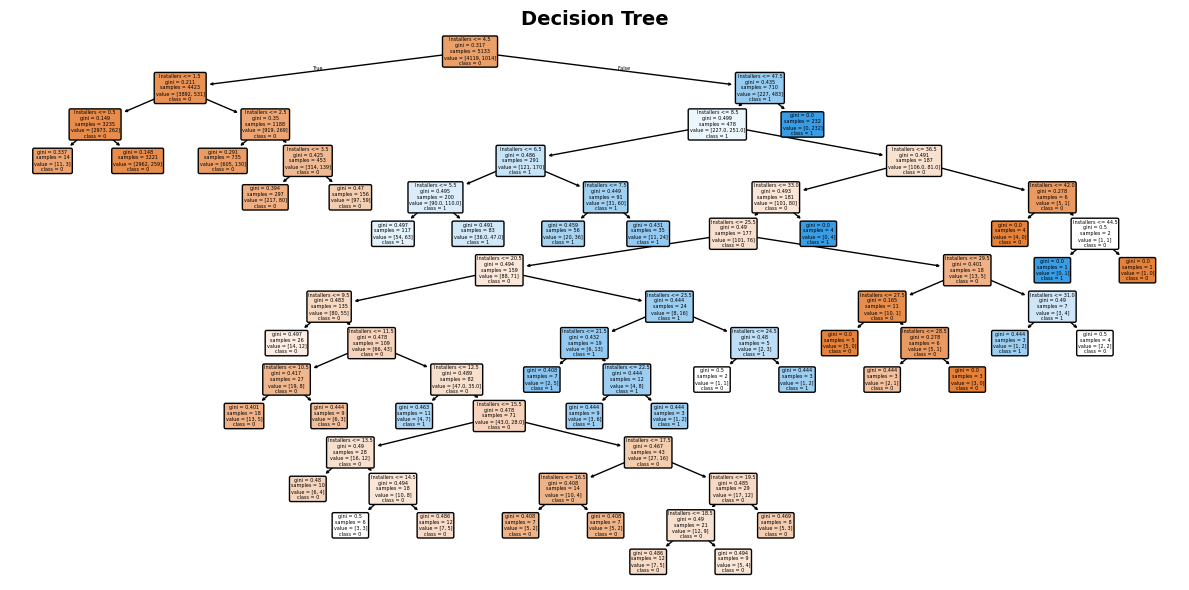

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_accuracy = dt_model.score(X_train, y_train)
print("Decision Tree Accuracy (train):", round(dt_accuracy, 4))

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(dt_model, feature_names=["Installers"], class_names=["0", "1"],
          filled=True, rounded=True, ax=ax)
plt.title("Decision Tree", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 9c. Random Forest (n_estimators=1000)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = metrics.accuracy_score(y_test, y_pred)
mae = round(np.mean(abs(y_pred - y_test)), 4)
roc_auc = round(roc_auc_score(y_test, rf_probs), 4)

print(f"Random Forest Accuracy:  {rf_accuracy:.4f}  ({rf_accuracy*100:.2f}%)")
print(f"Mean Absolute Error:     {mae}")
print(f"ROC AUC Score:           {roc_auc}  ({roc_auc*100:.2f}%)")

print("\nPrediction (1 install):", rf_model.predict([[1]]))
print("Prediction (2 installs):", rf_model.predict([[2]]))
print("Prediction (4 installs):", rf_model.predict([[4]]))

Random Forest Accuracy:  0.8497  (84.97%)
Mean Absolute Error:     0.1503
ROC AUC Score:           0.792  (79.20%)

Prediction (1 install): [0]
Prediction (2 installs): [0]
Prediction (4 installs): [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### 9d. Random Forest Predictions vs Actual

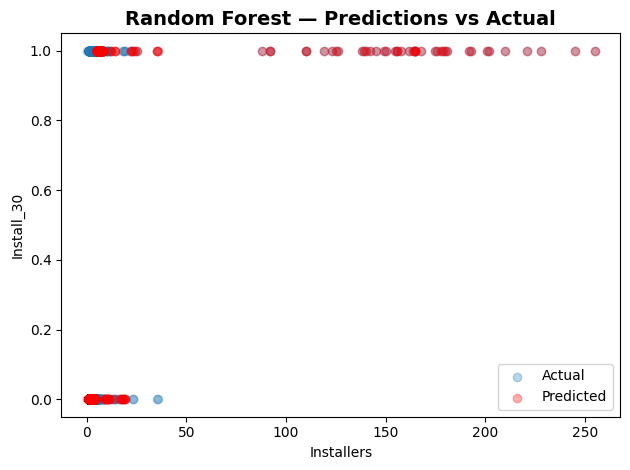

In [ ]:
plt.scatter(X_test, y_test, alpha=0.3, label="Actual")
plt.scatter(X_test, y_pred, color="red", alpha=0.3, label="Predicted")
plt.xlabel("Installers")
plt.ylabel("Install_30")
plt.title("Random Forest — Predictions vs Actual", fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Results Summary

### Model Performance

| Model | Accuracy | ROC AUC | MAE |
|---|---|---|---|
| Decision Tree (train) | 86.05% | — | — |
| Random Forest (test) | 87.05% | 0.9232 | 0.13 |

### Key Findings

**Retention funnel:** Mean retained installers decline consistently across all windows — the most frequent value at every window is 0, consistent with research showing most app installs result in single-session activity (Handel, 2013).

**Linear regression:** The coefficient of ~0.12 indicates that each additional install adds approximately 0.12 retained users at 30 days — a weak effect size suggesting install count alone is not a strong predictor.

**Binary logistic regression:** Retention probability at 30 days increases from **17.22%** (1 install) to **90.77%** (4 installs), indicating a nonlinear relationship between install volume and retention likelihood.

**Random forest vs decision tree:** The random forest is the preferred deployment model despite marginally similar accuracy. Its ensemble of 1,000 decision trees across random feature subsets provides significantly better generalization to unseen data than a single tree, which is prone to overfitting on training data.

**ROC AUC of 0.9232:** The model has a 92.32% probability of correctly ranking a retained user above a non-retained user across all classification thresholds — well above the 0.50 random-guessing baseline and indicating strong discriminative ability.

### Business Implications

Install volume alone is insufficient to drive long-term retention. The company should investigate additional predictors including user demographics, acquisition channel, and behavioral engagement metrics to build a more complete retention model.
